# Part 4 walkthrough — neural exercise boundary (PyTorch)

Run `python run_part4.py` first (about 1.5 min on 2 CPU threads). It trains all four cases and saves the tables and figures this notebook reads. All the modelling code is in `nn_policy.py`.

**Modelling choices that are ours** (everything else follows the assignment):
* The path-bank draw order follows the supplied README: $J$, then $S_J\sim A$, then the normals. Torch runs with 2 threads, 1 inter-op thread and deterministic algorithms.
* The in-the-money indicator uses $S_j<K$ on the path. Dates before $J$ get $p_j=0$, so they neither stop nor discount.
* Supervised targets are the stored float64 LS thresholds, cast to float32.

In [1]:
import numpy as np, pandas as pd, torch
pd.set_option("display.width", 160)
import config as cfg, simulation as sim, nn_policy as NP
from IPython.display import Image
print("torch", torch.__version__, "threads", torch.get_num_threads())

torch 2.14.0+cu130 threads 2


## Step 1 — The model maps each date to its own interval network

For $\delta>0$ there are four networks. A dividend date belongs to the interval that **starts** there (post-jump). The cap $U_j$ multiplies the sigmoid, so the boundary can never exceed the Part 1 bound.

In [2]:
for c in (0, 1):
    N, d = sim.CASES[c]; tg = cfg.TimeGrid(N)
    torch.manual_seed(5000 + c); m = NP.BoundaryModel(tg, d)
    print(f"case {c}: {len(m.nets)} net(s); interval of j = 0, d1-1, d1, d3 ->",
          m.interval[[0, tg.div_idx[0]-1, tg.div_idx[0], tg.j_star]].tolist(),
          "| params:", sum(p.numel() for p in m.parameters()))

case 0: 1 net(s); interval of j = 0, d1-1, d1, d3 -> [0, 0, 0, 0] | params: 25
case 1: 4 net(s); interval of j = 0, d1-1, d1, d3 -> [0, 0, 1, 3] | params: 100


## Step 2 — Is the randomised-stopping objective right?

As $\epsilon\to0$ the soft objective must equal the hard-rule payoff. We check this with the LS boundary on a throw-away bank.

In [3]:
display(pd.read_csv("tables/p4_soft_limit_check.csv"))

,case,eps,soft_mean,hard_mean,abs_diff
0,0,1.000000e-07,59.051164,59.051164,0.000000e+00
1,1,1.000000e-07,60.120135,60.120135,0.000000e+00
2,2,1.000000e-07,58.595628,58.595628,7.193347e-08
3,3,1.000000e-07,59.104330,59.104330,0.000000e+00


## Step 3 — Training curves

The supervised loss drops quickly for $\delta=0$ (one smooth curve to match). It stalls higher for $\delta>0$: the LS targets have spikes, and hitting the cap exactly needs sigmoid$\to1$.

The payoff objective is noisy because random start states make batch means vary by about \$1. That noise matters for Step 4.

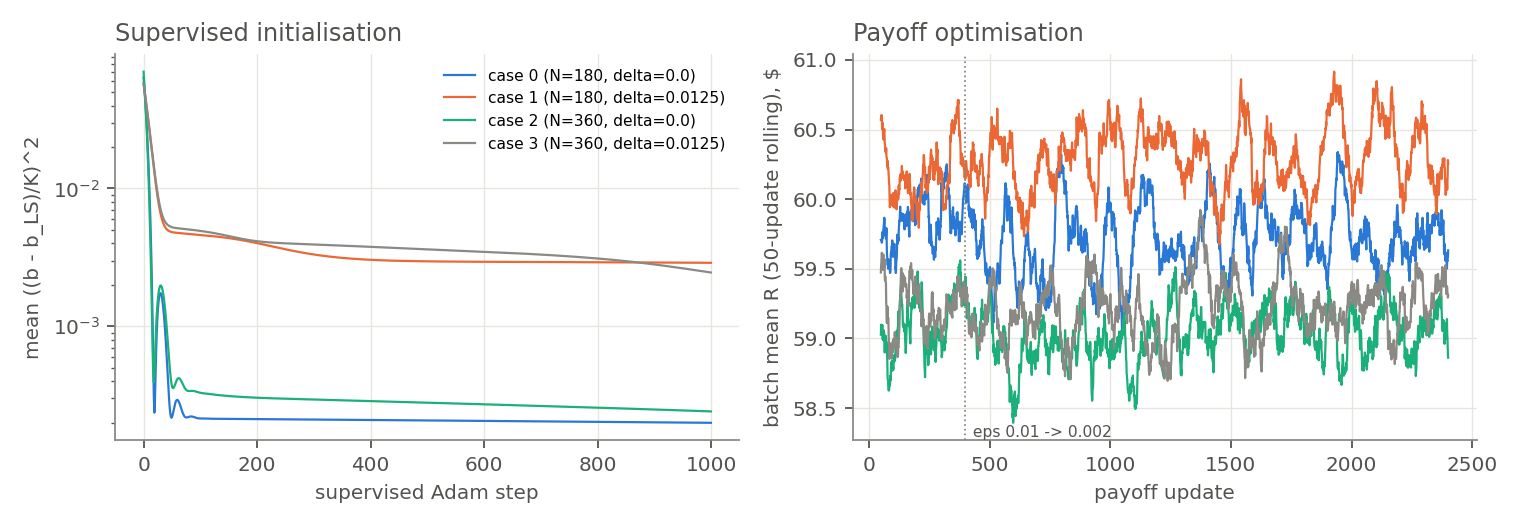

In [4]:
Image("figures/p4_training.png")

## Step 4 — Validation and checkpoint selection

,case,N,delta,val_mean_ckpt0,selected_checkpoint,val_mean_selected,sup_loss_final,time_supervised_s,time_banks_s,time_payoff_s,time_validation_s
0,0,180,0.0000,59.155065,2000,59.162622,0.000200,1.616113,0.137638,7.369195,0.016757
1,1,180,0.0125,58.988297,2000,59.015554,0.002890,1.224292,0.122828,9.339963,0.016982
2,2,360,0.0000,59.392109,1200,59.394530,0.000241,0.631689,0.245708,11.373172,0.030034
3,3,360,0.0125,60.531827,2400,60.555032,0.002458,1.453466,0.217961,12.602015,0.031840


,case,N,delta,checkpoint,val_mean,diff_vs_ckpt0,se_diff,E_mean_vs_ref,E_max_vs_ref,selected
0,0,180,0.0000,0,59.155065,0.000000,0.000000,0.068767,0.215219,False
1,0,180,0.0000,400,59.159691,0.004626,0.007157,0.069848,0.221401,False
2,0,180,0.0000,800,59.150617,-0.004448,0.007672,0.067333,0.224193,False
3,0,180,0.0000,1200,59.152496,-0.002569,0.016897,0.057035,0.218979,False
4,0,180,0.0000,1600,59.144980,-0.010085,0.005914,0.065097,0.213088,False
5,0,180,0.0000,2000,59.162622,0.007557,0.005969,0.071753,0.222223,True
6,0,180,0.0000,2400,59.145383,-0.009682,0.006126,0.064741,0.213049,False
7,1,180,0.0125,0,58.988297,0.000000,0.000000,0.019317,0.135776,False
8,1,180,0.0125,400,58.995422,0.007125,0.020584,0.021379,0.163006,False
9,1,180,0.0125,800,59.013680,0.025383,0.023663,0.019830,0.158322,False


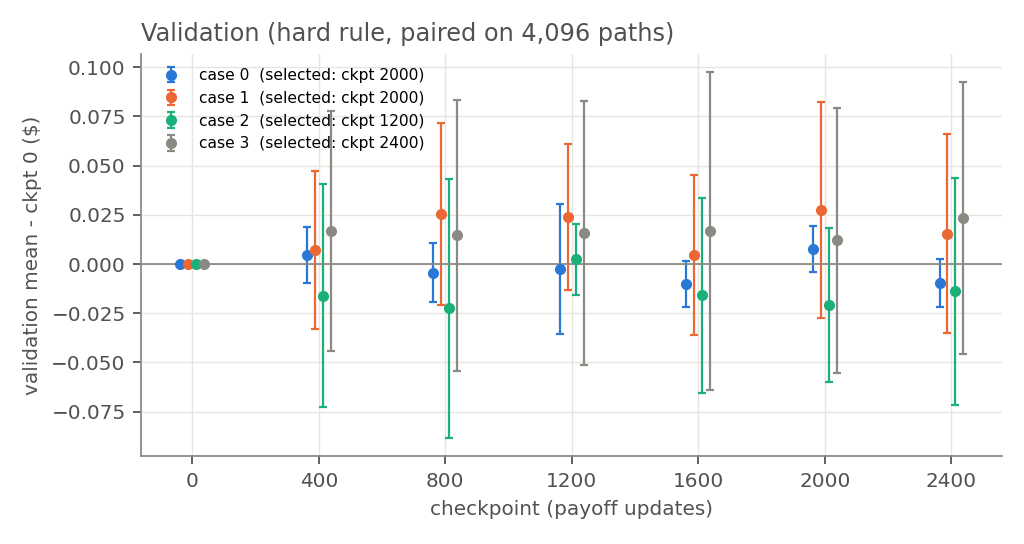

In [5]:
display(pd.read_csv("tables/p4_summary.csv"))
display(pd.read_csv("tables/p4_validation.csv"))
Image("figures/p4_validation.png")

**Reading.**
* All selected gains are within about 1.3 paired SE of zero, so selection is close to picking among statistically equal checkpoints. Checkpoint 0 was never selected.
* Payoff training barely changed the boundary error in cases 0–2.
* In case 3 it made the boundary worse ($E_{mean}$ 0.029 → 0.043): the network overshoots just after $d_1$. The validation mean barely reacts, because the value is flat near the optimal threshold.

## Step 5 — Independent evaluation (float64, 50,000 fresh paths per start)

method             LS         NN  ref-boundary policy
case S0                                              
0    60.0   40.000000  40.000000            40.000000
     80.0   20.661120  20.632064            20.843846
     100.0   8.639783   8.623239             8.773429
1    60.0   40.000000  40.000000            40.000000
     80.0   22.016996  22.028647            22.041170
     100.0  10.042580  10.047684            10.086181
2    60.0   40.000000  40.000000            40.000000
     80.0   20.600948  20.633082            20.849498
     100.0   8.585658   8.593435             8.714510
3    60.0   40.000000  39.954964            40.000000
     80.0   22.087032  22.027306            22.109971
     100.0  10.071607  10.068485            10.094813

,case,pair,S0,mean_diff,se
0,0,LS - NN,60.0,0.000000,0.000000
1,0,LS - ref-boundary policy,60.0,0.000000,0.000000
2,0,NN - ref-boundary policy,60.0,0.000000,0.000000
3,0,LS - NN,80.0,0.029056,0.010236
4,0,LS - ref-boundary policy,80.0,-0.182726,0.033699
5,0,NN - ref-boundary policy,80.0,-0.211782,0.034668
6,0,LS - NN,100.0,0.016544,0.006320
7,0,LS - ref-boundary policy,100.0,-0.133646,0.023399
8,0,NN - ref-boundary policy,100.0,-0.150190,0.023847
9,1,LS - NN,60.0,0.000000,0.000000


,case,N,delta,method,E_mean,E_max,j_at_max
0,0,180,0.0000,LS,0.068712,0.203524,177
1,0,180,0.0000,NN,0.071753,0.222223,179
2,1,180,0.0125,LS,0.033892,0.237071,152
3,1,180,0.0125,NN,0.017418,0.155077,170
4,2,360,0.0000,LS,0.063876,0.218541,359
5,2,360,0.0000,NN,0.061941,0.219736,359
6,3,360,0.0125,LS,0.037156,0.291560,300
7,3,360,0.0125,NN,0.042552,0.172694,296


,N,method,A,B,F
0,180,LS,0.0,0.000000,0.066405
1,180,NN,21.0,0.051476,0.081677
2,180,ref,0.0,0.000000,0.000000
3,180,ref: max (V0 - V0.0125)^+ $,NaN,NaN,0.000000
4,360,LS,0.0,0.000000,0.093846
5,360,NN,36.0,0.051213,0.171841
6,360,ref,0.0,0.000000,0.000000
7,360,ref: max (V0 - V0.0125)^+ $,NaN,NaN,0.000000


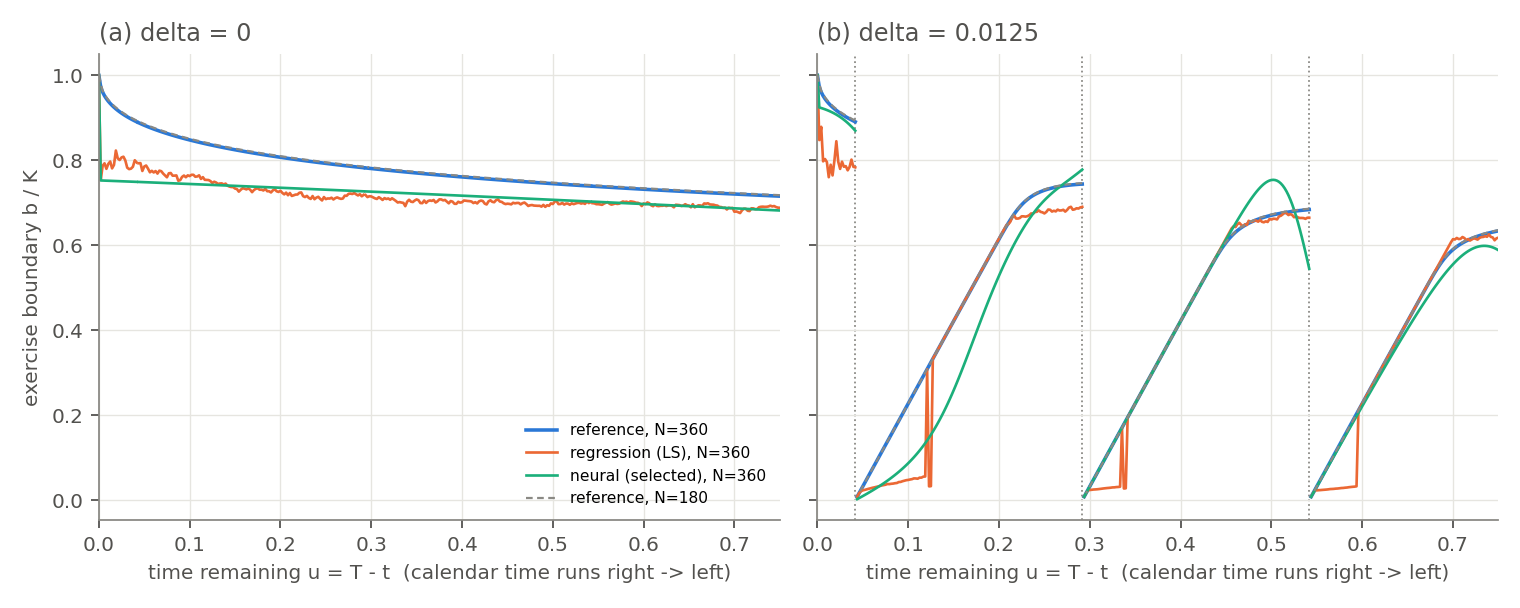

In [6]:
p = pd.read_csv("tables/p5_prices.csv")
display(p.pivot_table(index=["case","S0"], columns="method", values="mean"))
display(pd.read_csv("tables/p5_paired.csv"))
display(pd.read_csv("tables/p5_boundary_errors.csv"))
display(pd.read_csv("tables/p1_ordering_checks.csv"))
Image("figures/fig1_boundaries.png")